In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
df = pd.read_csv("/Users/athipongjindaphram/Documents/Python For Data Analyst/data_jobs.csv")
#Cleaning Date Column -> Type : Date time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [31]:
df_da_us = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()

In [32]:
df_da_us = df_da_us.dropna(subset=["salary_year_avg"])

df_da_us_explode = df_da_us.explode("job_skills")

df_da_us_explode[["salary_year_avg", "job_skills"]].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [33]:
df_da_skills = df_da_us_explode.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="count", ascending=False)

df_da_skills = df_da_skills.rename(columns={"count" : "skill_count", "median" : "median_salary"})

da_job_count = len(df_da_us)

df_da_skills["skill_percent"] = df_da_skills["skill_count"] / da_job_count * 100

skill_percent = 5

df_da_skill_high_demand = df_da_skills[df_da_skills["skill_percent"] > skill_percent]

In [34]:
from adjustText import adjust_text

In [ ]:
from matplotlib.ticker import PercentFormatter
df_da_skill_high_demand.plot(kind="scatter", x="skill_percent", y="median_salary")

text = []
for i, txt in enumerate(df_da_skill_high_demand.index):
    text.append(plt.text(df_da_skill_high_demand["skill_percent"].iloc[i], df_da_skill_high_demand["median_salary"].iloc[i], txt))

adjust_text(text, arrowprops=dict(arrowstyle="->", color="gray"))

plt.xlabel("Count of Job Posting")
plt.ylabel("Median Yearly Salary")
plt.title(f"Most Optimal Skills for Data Analysts in the US")

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

NameError: name 'df_plot' is not defined

In [40]:
df_technology = df["job_type_skills"].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

            

In [42]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=["technology", "skills"])

df_technology = df_technology.explode("skills")

df_technology

,technology,skills
0,analyst_tools,qlik
0,analyst_tools,alteryx
0,analyst_tools,sap
0,analyst_tools,ssrs
0,analyst_tools,datarobot
...,...,...
9,sync,rocketchat
9,sync,webex
9,sync,google chat
9,sync,ringcentral


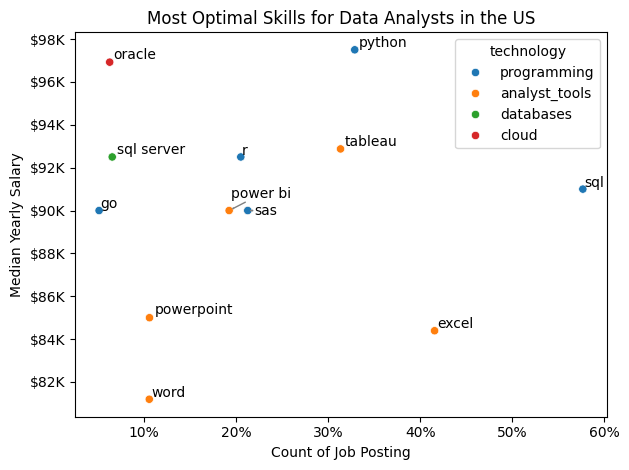

In [53]:
df_plot = df_da_skill_high_demand.merge(df_technology, left_on="job_skills", right_on="skills")

from matplotlib.ticker import PercentFormatter
#df_plot.plot(kind="scatter", x="skill_percent", y="median_salary")
sns.scatterplot(
    data=df_plot,
    x="skill_percent",
    y="median_salary",
    hue="technology"
)
text = []
for i, txt in enumerate(df_da_skill_high_demand.index):
    text.append(plt.text(df_da_skill_high_demand["skill_percent"].iloc[i], df_da_skill_high_demand["median_salary"].iloc[i], txt))

adjust_text(text, arrowprops=dict(arrowstyle="->", color="gray"))

plt.xlabel("Count of Job Posting")
plt.ylabel("Median Yearly Salary")
plt.title(f"Most Optimal Skills for Data Analysts in the US")

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()